# Transmon Qubit: Numerical Simulation and Spectra Computation

This notebook demonstrates the numerical simulation of a **transmon qubit** coupled to a microwave resonator. It covers:

1. **Transmon energy spectrum** as a function of offset charge $n_g$
2. **Coupled system** (transmon + resonator): eigenenergies and anticrossing
3. **Microwave transmission spectra** computed via the Rust extension `spectra_calculation`
4. **Dispersive shift** $\chi$ from perturbation theory vs. numerical result

The transmon is modeled by the Hamiltonian:
$$H = 4E_C(\hat{n} - n_g)^2 - E_J \cos(\hat{\varphi})$$
where $E_C$ is the charging energy, $E_J$ the Josephson energy, and $n_g$ the offset charge.
When $E_J/E_C \gg 1$, the qubit becomes insensitive to charge noise — the transmon regime.

## 1. Setup

In [1]:
import os

N_THREADS = '4'
os.environ['OMP_NUM_THREADS'] = N_THREADS
os.environ['OPENBLAS_NUM_THREADS'] = N_THREADS
os.environ['MKL_NUM_THREADS'] = N_THREADS

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import transmon_tools as transmon
import spectra_calculation

%matplotlib inline
plt.rcParams.update({'font.size': 12})

### Physical parameters

These correspond to a typical transmon-in-resonator circuit QED experiment.
Energies are in GHz (i.e. $E/h$).

In [2]:
EC  = 0.247   # Charging energy (GHz)
fr  = 3.884   # Resonator frequency (GHz)
g   = 0.647   # Qubit-resonator coupling (GHz)
ng  = 0.0     # Offset charge (in units of 2e)

n_max = 200   # Charge basis cutoff: states from -n_max to n_max

## 2. Transmon energy spectrum vs. offset charge $n_g$

The key feature of the transmon is that at large $E_J/E_C$ the energy levels become
flat as a function of $n_g$, making the qubit frequency insensitive to charge noise.
Below we compare three regimes: $E_J/E_C = 3$, $10$, and $40$.

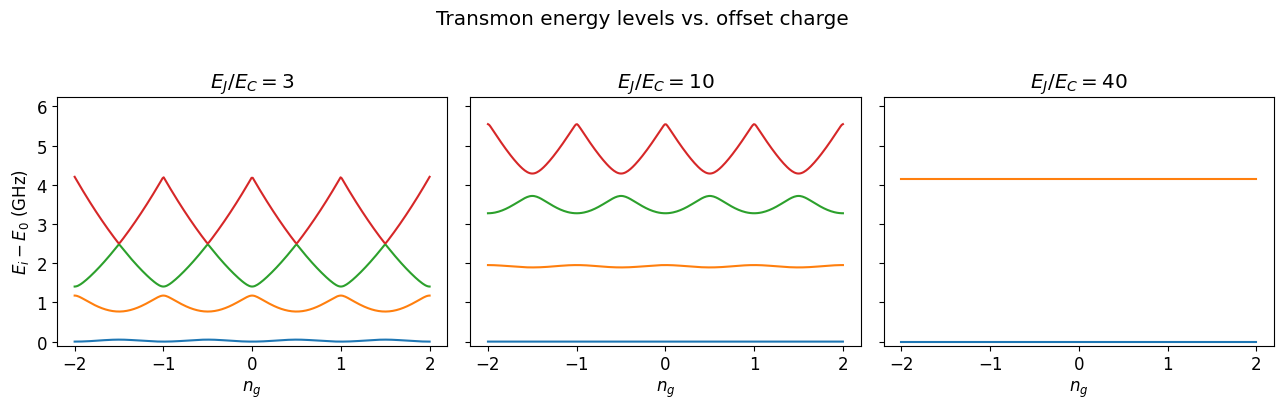

In [3]:
ng_arr = np.linspace(-2, 2, 300)
n_levels = 4  # Number of energy levels to plot

ratios = [3, 10, 40]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, ratio in zip(axes, ratios):
    EJ = EC * ratio
    E = np.zeros((2 * n_max + 1, len(ng_arr)))
    for j, n in enumerate(ng_arr):
        E[:, j] = transmon.numerical_transmon_E(EJ, EC, n, n_max, eigvals_only=True)

    for level in range(n_levels):
        ax.plot(ng_arr, E[level, :] - E[0, :].min())

    ax.set_title(f'$E_J/E_C = {ratio}$')
    ax.set_xlabel('$n_g$')
    ax.set_ylim(-0.1, 4 * EC * ratio**0.5)

axes[0].set_ylabel('$E_i - E_0$ (GHz)')
fig.suptitle('Transmon energy levels vs. offset charge', y=1.02)
plt.tight_layout()
plt.show()

The charge dispersion — the peak-to-peak variation of the qubit frequency with $n_g$ —
decreases exponentially with $E_J/E_C$, which is the central advantage of the transmon design.

## 3. Transmon coupled to a microwave resonator

We now include the coupling to a resonator with frequency $f_r$ and compute
the eigenstates of the full system, sorting them by parity.
The spectrum shows an **anticrossing** when the qubit frequency $f_q \approx f_r$.

In [4]:
A = 10   # Resonator Fock space truncation
N = 10   # Number of transmon levels
n_fqs = 3

EJ_arr = np.linspace(2, 100, 120) * EC

fq_num, G, even_energies, even_states, odd_energies, odd_states = transmon.sorted_energies(
    A, N, EJ_arr, EC, ng, fr, g, n_fqs=n_fqs
)

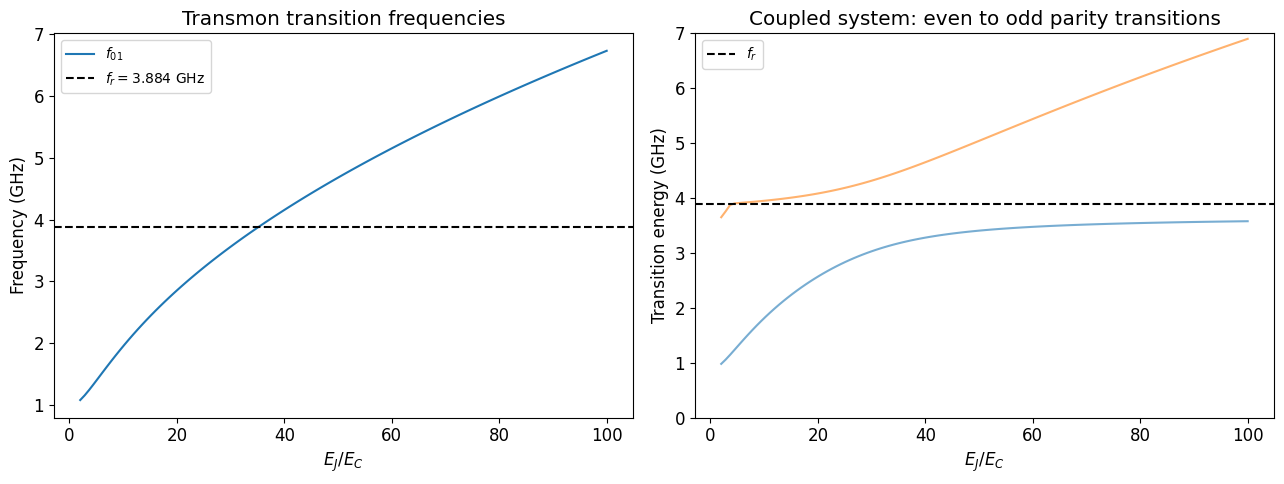

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bare transmon transition vs EJ/EC
ax = axes[0]
for k in range(n_fqs-2):
    ax.plot(EJ_arr / EC, fq_num[k, :], label=f'$f_{{0{k+1}}}$')
ax.axhline(fr, color='k', linestyle='--', label=f'$f_r = {fr}$ GHz')
ax.set_xlabel('$E_J / E_C$')
ax.set_ylabel('Frequency (GHz)')
ax.set_title('Transmon transition frequencies')
ax.legend(fontsize=10)

# Right: coupled system — first few transition energies showing the anticrossing
ax = axes[1]
ax.plot(EJ_arr / EC, odd_energies[0, :] - even_energies[0, :], alpha=0.6)
ax.plot(EJ_arr / EC, odd_energies[1, :] - even_energies[0, :], alpha=0.6)
ax.axhline(fr, color='k', linestyle='--', label=f'$f_r$')
ax.set_xlabel('$E_J / E_C$')
ax.set_ylabel('Transition energy (GHz)')
ax.set_title('Coupled system: even to odd parity transitions')
ax.set_ylim(0, 7)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 4. Microwave transmission spectra (Rust extension)

The transmission spectrum is computed by summing Lorentzian contributions
from all pairs of eigenstates:

$$S(f) = \sum_{j,k} |\langle j | \hat{O} | k \rangle|^2 \cdot \frac{w/2\pi}{(w/2)^2 + (f - |E_j - E_k|)^2}$$

where $\hat{O}$ is the relevant transition operator and $w$ is the linewidth.
This inner loop is parallelized in Rust via Rayon, which gives a significant
speedup over a pure Python implementation for large Hilbert spaces.

Three channels are computed:
- **T01**: single-photon transitions (ground → first excited manifold)
- **T2ph**: two-photon transitions
- **T12**: sideband transitions (first → second excited manifold)

In [6]:
num_f = 800
f = np.linspace(1.0, 14.0, num_f)  # Frequency axis (GHz)
w = 0.05                          # Lorentzian linewidth (GHz)

# Convert QuTiP objects to numpy arrays for the Rust extension
even_states_np = np.array([[s.full() for s in row] for row in even_states]).squeeze(-1).transpose(1, 0, 2)
odd_states_np  = np.array([[s.full() for s in row] for row in odd_states]).squeeze(-1).transpose(1, 0, 2)
G_np           = np.array([gi.full() for gi in G])

# State populations: system in ground even-parity state
n_E = int(A * N / 2)
state_population_E = np.zeros(n_E)
state_population_O = np.zeros(n_E)
state_population_E[0] = 0.7
state_population_O[0] = 0.3

# Compute 2D spectra (sweeping EJ)
_, Stotal_T, Stotal_T2ph, Stotal_T12 = spectra_calculation.calculate_spectra_2D(
    A, N,
    3,   # peaks_01: number of single-photon transitions included
    1,   # peaks_2ph
    1,   # peaks_12
    w, list(f),
    list(state_population_E),
    list(state_population_O),
    even_energies, even_states_np,
    odd_energies,  odd_states_np,
    G_np
)

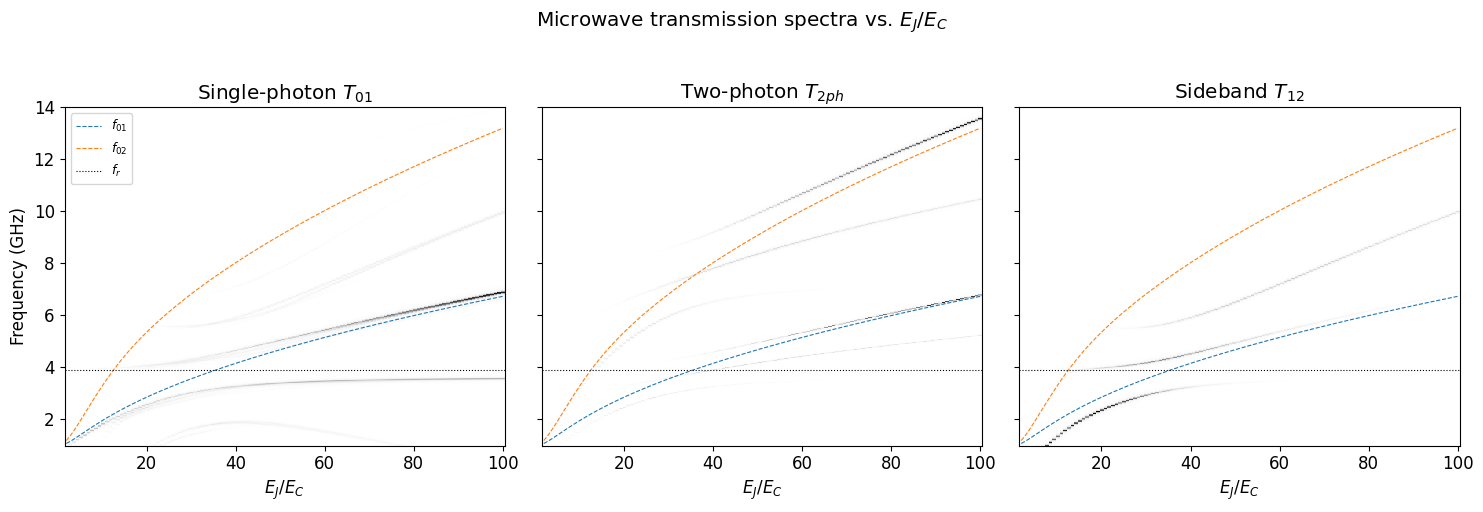

In [7]:
X, Y = np.meshgrid(EJ_arr / EC, f)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles  = ['Single-photon $T_{01}$', 'Two-photon $T_{2ph}$', 'Sideband $T_{12}$']
spectra = [Stotal_T, Stotal_T2ph, Stotal_T12]

for ax, S, title in zip(axes, spectra, titles):
    ax.pcolormesh(X, Y, S.T, cmap='Greys', shading='auto')
    # Overlay bare qubit frequency
    for k in range(min(n_fqs, 2)):
        ax.plot(EJ_arr / EC, fq_num[k, :], lw=0.8, linestyle='--', label=f'$f_{{0{k+1}}}$')
    ax.axhline(fr, color='k', lw=0.8, linestyle=':', label='$f_r$')
    ax.set_xlabel('$E_J / E_C$')
    ax.set_title(title)
    ax.set_ylim(f.min(), f.max())

axes[0].set_ylabel('Frequency (GHz)')
axes[0].legend(fontsize=9)
fig.suptitle('Microwave transmission spectra vs. $E_J/E_C$', y=1.02)
plt.tight_layout()
plt.show()

## 5. Dispersive shift $\chi$

In the dispersive regime ($|f_q - f_r| \gg g$), the qubit-resonator coupling shifts
the resonator frequency by $\pm\chi$ depending on the qubit state. To second order
in $g$, including counter-rotating terms (beyond RWA):

$$\chi = \chi_{01} - \frac{\chi_{12}}{2}, \quad
\chi_{ij} = -\left(\frac{|g_{ij}|^2}{f_r - f_{ij}} - \frac{|g_{ij}|^2}{f_r + f_{ij}}\right)$$

We compare this perturbative expression to the numerical result extracted from the
parity-sorted spectrum.

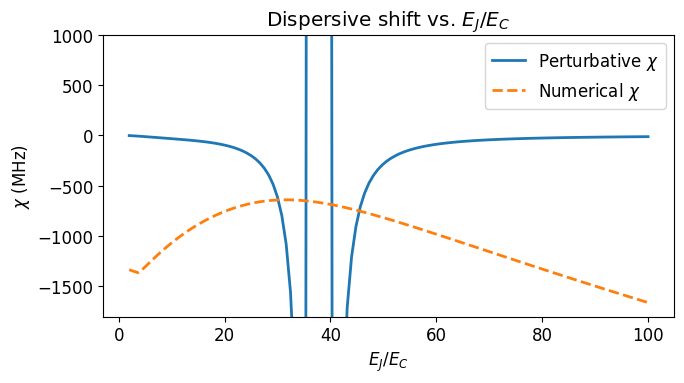

In [8]:
def chi_perturbative(G_vals, fq_vals, fr):
    """Second-order dispersive shift including counter-rotating terms."""
    g01, g12 = np.abs(G_vals[0]), np.abs(G_vals[1])
    f01, f12 = fq_vals[0], fq_vals[1] - fq_vals[0]
    chi_01 = -(g01**2 / (fr - f01) - g01**2 / (fr + f01))
    chi_12 = -(g12**2 / (fr - f12) - g12**2 / (fr + f12))
    return chi_01 - chi_12 / 2

# G[:,0,1] and G[:,1,2] are the 01 and 12 coupling matrix elements
G_chi = np.array([G_np[:, 0, 1], G_np[:, 1, 2]])
chi = np.array([
    chi_perturbative(G_chi[:, m], fq_num[:, m], fr)
    for m in range(len(EJ_arr))
])

# Numerical chi: half the splitting between the two lowest-energy transitions
chi_numerical = ((odd_energies[0, :] - even_energies[0, :]) -
                 (odd_energies[1, :] - even_energies[0, :])) / 2

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(EJ_arr / EC, chi * 1e3,           label='Perturbative $\\chi$', lw=2)
ax.plot(EJ_arr / EC, chi_numerical * 1e3, label='Numerical $\\chi$',    lw=2, linestyle='--')
ax.set_xlabel('$E_J / E_C$')
ax.set_ylabel('$\\chi$ (MHz)')
ax.set_title('Dispersive shift vs. $E_J/E_C$')
ax.legend()
ax.set_ylim(-1800, 1000)
plt.tight_layout()
plt.show()

The perturbative expression breaks down near the resonance ($f_q \approx f_r$, i.e. small $E_J/E_C$)
and also at large coupling where higher-order terms become important.
The numerical calculation remains valid throughout.